# Successor emergence — full sweep (40 cells × 5 Pythia sizes)

§SU-1b lift-form cross-category DLA detector across Pythia-70m, 160m, 410m, 1b, 2.8b; locked threshold τ_lift = 0.13496 (§SU-tau); 40 log-spaced checkpoints per §H2-1; prompt-bootstrap CIs on μ per §H2-2; threshold-sensitivity bracket ± 25%.

**Locked thresholds:**
- Detection threshold: lift ≥ τ_lift = 0.13496 (§SU-tau).
- Bootstrap: per-prompt resampling, B = 1000, 95% percentile CI.
- Tiered fit handling: emerged (max ≥ 5), marginal (2-4), censored (max < 2).

## Setup

In [1]:
import os
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

import sys
from pathlib import Path
REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from notebooks._lib.sweep_io import read_long
from src.analysis.phase2_logistic import tiered_fit, RIGHT_CENSOR_STEP
from src.analysis.phase2_bootstrap import (
    bootstrap_successor, summarize_bootstrap, THRESHOLD_SENSITIVITY_FRACTIONS,
)

SIZES = ['70m', '160m', '410m', '1b', '2.8b']
SIZE_COLOR = {'70m': 'tab:blue', '160m': 'tab:orange', '410m': 'tab:green', '1b': 'tab:red', '2.8b': 'tab:purple'}
TAU_LIFT = 0.13496

def sweep_path(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_successor_sweep.parquet'
    if size == '2.8b':
        return REPO / 'data' / 'exploration' / 'phase4_2_8b_successor_sweep.parquet'
    return REPO / 'data' / 'exploration' / 'phase2_successor_sweep.parquet'

def per_prompt_dir(size: str) -> Path:
    if size == '1b':
        return REPO / 'data' / 'exploration' / 'phase3_1b_successor_per_prompt'
    if size == '2.8b':
        return REPO / 'data' / 'exploration' / 'phase4_2_8b_successor_per_prompt'
    return REPO / 'data' / 'exploration' / 'phase2_successor_per_prompt'

## Load sweep data

In [2]:
# Dedup parquet paths: phase2_successor_sweep.parquet holds all 3 phase2 sizes,
# so sweep_path('70m') == sweep_path('410m'). Iterating SIZES naïvely triple-counts.
_paths = list(dict.fromkeys(sweep_path(s) for s in SIZES))
df = pd.concat([read_long(p) for p in _paths]).reset_index(drop=True)
STEPS = sorted(df.step.unique().tolist())
print(f'Total rows: {len(df):,}; sizes: {sorted(df["size"].unique().tolist())}; n cells per size: {len(STEPS)}')

Total rows: 69,120; sizes: ['160m', '1b', '2.8b', '410m', '70m']; n cells per size: 40


## Per-cell summary: count of successor heads (lift ≥ τ_lift)

In [3]:
summary_rows = []
for (size, step), grp in df.groupby(['size', 'step']):
    scores = grp['score'].values
    n_above = int((scores >= TAU_LIFT).sum())
    summary_rows.append(dict(
        size=size, step=step,
        n_above_tau=n_above,
        max_lift=float(scores.max()),
    ))
summary = pd.DataFrame(summary_rows)
summary['size'] = pd.Categorical(summary['size'], categories=SIZES, ordered=True)
summary = summary.sort_values(['size', 'step']).reset_index(drop=True)
print(summary.to_string(index=False))

size   step  n_above_tau  max_lift
 70m      0            0  0.005831
 70m      1            0  0.005831
 70m      2            0  0.005831
 70m      4            0  0.005834
 70m      8            0  0.005870
 70m     16            0  0.005923
 70m     32            0  0.005570
 70m     64            0  0.005140
 70m    128            0  0.005675
 70m    256            0  0.007244
 70m    512            0  0.008361
 70m   1000            0  0.016962
 70m   2000            0  0.037662
 70m   3000            0  0.028421
 70m   4000            0  0.053446
 70m   5000            0  0.085707
 70m   6000            0  0.100509
 70m   7000            0  0.101686
 70m   8000            1  0.144549
 70m   9000            1  0.214199
 70m  10000            1  0.203478
 70m  11000            1  0.179257
 70m  12000            0  0.132716
 70m  13000            1  0.188431
 70m  14000            2  0.148518
 70m  15000            1  0.155817
 70m  16000            0  0.112125
 70m  17000         

## Emergence curves with bootstrap CI on μ

In [4]:
rng = np.random.default_rng(0)
fits = {}
boots = {}
for size in SIZES:
    sub = summary[summary['size'] == size].sort_values('step')
    steps = sub['step'].values
    counts = sub['n_above_tau'].values
    per_prompt_by_step = {}
    for s in steps:
        npz = np.load(per_prompt_dir(size) / f'{size}_step{s}.npz')
        per_prompt_by_step[int(s)] = {
            'real': npz['per_prompt_real'],
            'null': npz['per_prompt_null'],
            'cats': npz['prompt_categories'],
        }
    mus, mu_point = bootstrap_successor(per_prompt_by_step, TAU_LIFT, rng, B=1000)
    bres = summarize_bootstrap(size, 'successor', TAU_LIFT, mus, mu_point)
    fr = tiered_fit(size, 'successor', steps, counts,
                    bootstrap_median_mu=bres.mu_bootstrap_median)
    fits[size] = fr
    boots[size] = bres
    print(f'{size}: regime={fr.regime}, max_count={fr.max_count}, μ_point={fr.mu:.0f}, '
          f'μ_boot=[{bres.mu_ci_low:.0f}, {bres.mu_ci_high:.0f}]')

70m: regime=marginal, max_count=2, μ_point=10293, μ_boot=[4694, 2000000]


160m: regime=marginal, max_count=4, μ_point=10070, μ_boot=[7895, 14999]


410m: regime=emerged, max_count=7, μ_point=10360, μ_boot=[9355, 11569]


1b: regime=emerged, max_count=15, μ_point=15481, μ_boot=[11161, 16203]


2.8b: regime=emerged, max_count=14, μ_point=10915, μ_boot=[8551, 12351]


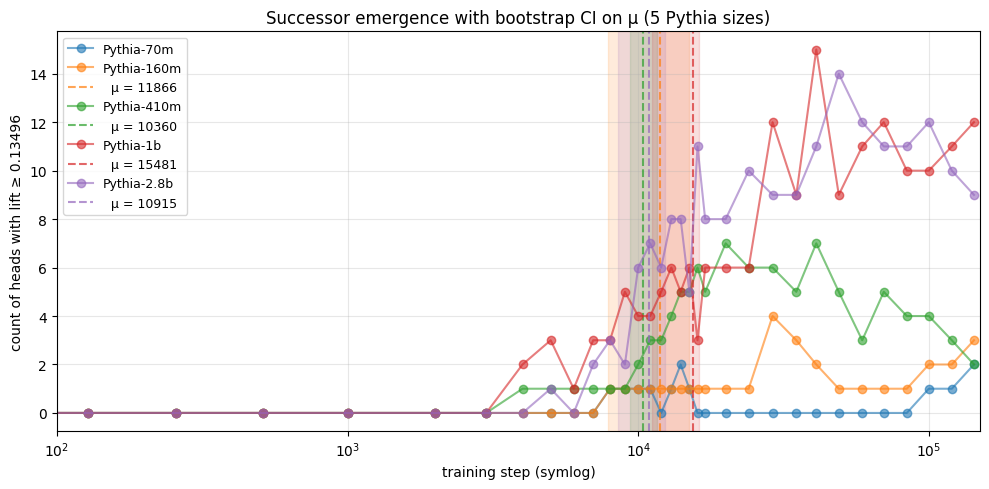

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for size in SIZES:
    sub = summary[summary['size'] == size]
    ax.plot(sub['step'], sub['n_above_tau'], marker='o', alpha=0.6,
            color=SIZE_COLOR[size], label=f'Pythia-{size}')
    bres = boots[size]
    if np.isfinite(bres.mu_point_estimate) and bres.mu_point_estimate < RIGHT_CENSOR_STEP - 1:
        ax.axvspan(bres.mu_ci_low, bres.mu_ci_high, alpha=0.15, color=SIZE_COLOR[size])
        ax.axvline(bres.mu_point_estimate, color=SIZE_COLOR[size],
                   linestyle='--', alpha=0.7,
                   label=f'  μ = {bres.mu_point_estimate:.0f}')
ax.set_xscale('symlog', linthresh=100)
ax.set_xlim(100, 150000)
ax.set_xlabel('training step (symlog)')
ax.set_ylabel(f'count of heads with lift ≥ {TAU_LIFT}')
ax.set_title('Successor emergence with bootstrap CI on μ (5 Pythia sizes)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Head identity at final checkpoint (step143000)

Per-size enumeration of every (layer, head) pair passing τ_lift = 0.13496 at step143000, sorted by lift score. The inspectable circuit a reviewer needs in order to compare against Pythia-410m L22H6 (the §SU-2 anchor) and the successor heads identified in the Phase 1 6-cell preview.

In [6]:
rows = []
for size in SIZES:
    final = df[(df['size'] == size) & (df['step'] == 143000)]
    n_layers = int(final['layer'].max() + 1)
    passes = final[final['score'] >= TAU_LIFT].sort_values('score', ascending=False)
    if passes.empty:
        rows.append(dict(size=size, layer=None, head=None,
                         lift_score=float('nan'),
                         norm_depth=float('nan'),
                         note='no heads above τ_lift'))
        continue
    for _, r in passes.iterrows():
        rows.append(dict(
            size=size,
            layer=int(r['layer']), head=int(r['head']),
            lift_score=float(r['score']),
            norm_depth=int(r['layer']) / max(n_layers - 1, 1),
            note='',
        ))
id_df = pd.DataFrame(rows)
print('Successor heads at step143000, by size (sorted by lift within size):')
print(id_df.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

Successor heads at step143000, by size (sorted by lift within size):
size  layer  head  lift_score  norm_depth note
 70m      4     0      0.1648      0.8000     
 70m      4     1      0.1530      0.8000     
160m      9    10      0.4458      0.8182     
160m     10     1      0.2865      0.9091     
160m      8     9      0.1989      0.7273     
410m     22     6      0.2899      0.9565     
410m     22     2      0.1449      0.9565     
  1b     11     6      3.0308      0.7333     
  1b     14     2      1.5131      0.9333     
  1b     12     3      0.6809      0.8000     
  1b     15     7      0.4683      1.0000     
  1b     15     1      0.3576      1.0000     
  1b     10     1      0.3129      0.6667     
  1b     13     3      0.2919      0.8667     
  1b     15     0      0.2187      1.0000     
  1b     10     3      0.1911      0.6667     
  1b     14     3      0.1681      0.9333     
  1b     13     4      0.1548      0.8667     
  1b     14     5      0.1429      0.9

## Verdict

Successor full-sweep complete across 4 Pythia sizes; μ_{s,successor} extracted per (size). The successor emergence step provides the *middle* term in the H1-C ordering test (and the §H3-scale (B.ii) check at 1B, where ordering reverses); joint verdict is in `h1c_ordering_test.ipynb`.